# 16 — Cross-Period Robustness (Setups A, B, C)

Checks whether the modelling approach generalizes across time periods, not just the single
Q1 2026 quarter (Setup B) the rest of this project is built around:

| Setup | History | Target quarter | Feature file |
|---|---|---|---|
| A | Jul-Sep 2025 (3 mo) | Q4 2025 | `train_local_setupA.parquet` |
| B (existing, primary) | Jul-Dec 2025 (6 mo) | Q1 2026 | `train_local.parquet` |
| C | Jul 2025-Jan 2026 (7 mo) | Feb-Apr 2026 | `train_local_setupC.parquet` |

**Models per setup** (reduced strong set, not the full 9-model Setup B roster -- this is a
robustness check, not a re-run of every existing analysis): Linear Regression, Random Forest,
XGBoost, LightGBM, CatBoost, plus an SLSQP-optimal blend. All hyperparameters are reused
verbatim from the existing tuned configs (`05_Gradient_Boosting_XGBoost.ipynb`'s
`xgb_v3_params`, `outputs/lightgbm_best_params.json`, `outputs/catboost_best_params.json`) --
no re-tuning per setup, since a robustness check should test whether the *same* approach
generalizes, not whether a freshly-tuned model can be made to fit each period.

**Protocol**, matching the rest of the project: 5-fold CV on the 80% development split for
model selection and blend-weight learning; a single held-out evaluation on the untouched 20%
test split for the unbiased figure of merit.

## 1. Setup

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
OUT = Path('../outputs')
RANDOM_STATE, N_SPLITS = 42, 5
TARGET, ID = 'blocked_days_Q1_2026', 'id'

print('Setup complete.')

Setup complete.


## 2. Shared Preprocessing Pipeline

Identical to `10_SOTA_and_diagnostics.ipynb`'s approach: median-impute numeric columns,
low-cardinality categoricals one-hot (in practice empty -- every setup's only remaining raw
categorical is the high-cardinality `neighbourhood_cleansed`), and a K-fold target encoder for
high-cardinality categoricals, fit inside each CV fold to stay leakage-safe. Reused unchanged
for all 5 models, including Linear Regression: unregularized OLS predictions are invariant to
linear rescaling of numeric inputs, so skipping a `StandardScaler` here costs Linear nothing
while keeping one pipeline for every model.

In [2]:
class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols, n_splits=5, smoothing=20.0, random_state=42):
        self.cols = cols; self.n_splits = n_splits
        self.smoothing = smoothing; self.random_state = random_state

    def _smap(self, x, yy):
        st = pd.DataFrame({'c': x, 'y': yy}).groupby('c')['y'].agg(['mean', 'count'])
        return ((st['count'] * st['mean'] + self.smoothing * self.gm_)
                / (st['count'] + self.smoothing)).to_dict()

    def fit(self, X, y):
        y = np.asarray(y, float); self.gm_ = float(y.mean())
        self.maps_ = {c: self._smap(X[c].astype(str).fillna('__nan__'), y) for c in self.cols}
        return self

    def transform(self, X):
        Xo = X.copy()
        for c in self.cols:
            Xo[c] = (X[c].astype(str).fillna('__nan__').map(self.maps_[c])
                       .fillna(self.gm_).astype('float32'))
        return Xo

    def fit_transform(self, X, y=None, **kw):
        y = np.asarray(y, float); self.gm_ = float(y.mean())
        Xo = X.copy()
        for c in self.cols:
            Xo[c] = np.full(len(X), self.gm_, dtype='float32')
        kf = KFold(self.n_splits, shuffle=True, random_state=self.random_state)
        for tr, va in kf.split(X):
            for c in self.cols:
                m = self._smap(X[c].astype(str).fillna('__nan__').iloc[tr], y[tr])
                Xo.iloc[va, Xo.columns.get_loc(c)] = (
                    X[c].astype(str).fillna('__nan__').iloc[va].map(m)
                       .fillna(self.gm_).astype('float32').values)
        self.maps_ = {c: self._smap(X[c].astype(str).fillna('__nan__'), y) for c in self.cols}
        return Xo


def make_pp(num_cols, cat_low, cat_high):
    return ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
        ('low', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_low),
        ('high', Pipeline([('te', KFoldTargetEncoder(cat_high, 5, 20.0, RANDOM_STATE))]), cat_high),
    ])

## 3. Model Configs (reused verbatim, no re-tuning)

In [3]:
# XGBoost v3 tuned config -- copied verbatim from 05_Gradient_Boosting_XGBoost.ipynb
# (n_estimators deliberately 1000, not 3000: more trees only overfit per that notebook's
# own experiments -- 295.7 vs 294.3 CV MSE on Setup B).
xgb_v3_params = {
    'n_estimators': 1000,
    'learning_rate': 0.0244,
    'max_depth': 6,
    'min_child_weight': 11,
    'subsample': 0.769,
    'colsample_bytree': 0.740,
    'gamma': 0.195,
    'reg_alpha': 0.0615,
    'reg_lambda': 4.514,
    'tree_method': 'hist',
    'n_jobs': -1,
}

with open(OUT / 'lightgbm_best_params.json') as f:
    lgb_params = json.load(f)
with open(OUT / 'catboost_best_params.json') as f:
    cat_params = json.load(f)

print('XGBoost v3 params:', xgb_v3_params)
print('LightGBM   params:', lgb_params)
print('CatBoost   params:', cat_params)

XGBoost v3 params: {'n_estimators': 1000, 'learning_rate': 0.0244, 'max_depth': 6, 'min_child_weight': 11, 'subsample': 0.769, 'colsample_bytree': 0.74, 'gamma': 0.195, 'reg_alpha': 0.0615, 'reg_lambda': 4.514, 'tree_method': 'hist', 'n_jobs': -1}
LightGBM   params: {'n_estimators': 3000, 'learning_rate': 0.03054448687973741, 'num_leaves': 112, 'min_child_samples': 31, 'subsample': 0.8586618852801327, 'colsample_bytree': 0.6906375341879244, 'reg_lambda': 0.5382982563953534}
CatBoost   params: {'iterations': 3000, 'learning_rate': 0.04297635897689506, 'depth': 7, 'l2_leaf_reg': 1.6892664616540376}


## 4. Setup Registry

In [4]:
SETUPS = [
    ('A', OUT / 'train_local_setupA.parquet', OUT / 'test_local_setupA.parquet', 92, 'Q4 2025'),
    ('B', OUT / 'train_local.parquet',        OUT / 'test_local.parquet',        90, 'Q1 2026'),
    ('C', OUT / 'train_local_setupC.parquet', OUT / 'test_local_setupC.parquet', 89, 'Feb-Apr 2026'),
]

MODEL_NAMES = ['LinearRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']

def make_ctor(name):
    if name == 'LinearRegression':
        return lambda seed: LinearRegression()
    if name == 'RandomForest':
        return lambda seed: RandomForestRegressor(random_state=seed, n_jobs=-1)
    if name == 'XGBoost':
        return lambda seed: XGBRegressor(**xgb_v3_params, random_state=seed, objective='reg:squarederror')
    if name == 'LightGBM':
        return lambda seed: LGBMRegressor(**lgb_params, random_state=seed, n_jobs=-1, verbose=-1)
    if name == 'CatBoost':
        return lambda seed: CatBoostRegressor(**cat_params, random_seed=seed, verbose=0)
    raise ValueError(name)

NEEDS_EARLY_STOP = {'LinearRegression': False, 'RandomForest': False,
                    'XGBoost': False, 'LightGBM': True, 'CatBoost': True}

print('Setups:', [s[0] for s in SETUPS])
print('Models:', MODEL_NAMES)

Setups: ['A', 'B', 'C']
Models: ['LinearRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']


## 5. Fit Helper

One shared function used for both the 5-fold OOF loop and the final held-out-test fit
(fit-on-full-train, predict-on-test is just `fold_fit(train, train_y, test, ...)` called once
instead of per-fold).

In [5]:
import lightgbm as lgb

def fold_fit(name, X_tr_raw, y_tr, X_va_raw, seed, num_cols, cat_low, cat_high, clip):
    pp = make_pp(num_cols, cat_low, cat_high)
    Xtr_full = pp.fit_transform(X_tr_raw, y_tr)
    Xva = pp.transform(X_va_raw)
    ctor = make_ctor(name)

    if NEEDS_EARLY_STOP[name]:
        Xtr, Xin, ytr2, yin = train_test_split(Xtr_full, y_tr, test_size=0.10, random_state=seed)
        m = ctor(seed)
        if name == 'LightGBM':
            m.fit(Xtr, ytr2, eval_set=[(Xin, yin)], callbacks=[lgb.early_stopping(50, verbose=False)])
        else:  # CatBoost
            m.fit(Xtr, ytr2, eval_set=(Xin, yin), use_best_model=True, verbose=False)
    else:
        m = ctor(seed)
        m.fit(Xtr_full, y_tr)

    pred = np.clip(m.predict(Xva), 0, clip)
    return pred

## 6. Per-Setup: 5-Fold CV (Dev) + SLSQP Blend + Held-Out Test

For each setup: load its own train/test files, run 5-fold CV for all 5 models to get OOF
predictions (used for model comparison and for learning the blend weights -- consistent with
how Setup B's own blend was built), then fit each model once on the *full* development set and
predict on the untouched held-out test split for the unbiased final number. The same
SLSQP-learned blend weights are then applied to the models' held-out test predictions to get
the blend's own held-out test score.

In [6]:
all_rows = []       # per-model-per-setup metrics (dev CV + held-out test)
oof_store = {}       # setup -> {model: oof array}
y_store = {}          # setup -> dev y array

for setup_name, train_path, test_path, clip, target_label in SETUPS:
    print(f'\n{"="*70}\nSETUP {setup_name}  (target: {target_label}, clip={clip})\n{"="*70}')
    train = pd.read_parquet(train_path)
    test  = pd.read_parquet(test_path)
    y = train[TARGET].astype(float).values
    X = train.drop(columns=[TARGET, ID], errors='ignore').reset_index(drop=True)
    y_test = test[TARGET].astype(float).values
    X_test = test.drop(columns=[TARGET, ID], errors='ignore').reindex(columns=X.columns).reset_index(drop=True)

    cat_all = X.select_dtypes(exclude='number').columns.tolist()
    card = {c: X[c].nunique(dropna=False) for c in cat_all}
    cat_high = [c for c, n in card.items() if n > 15]
    cat_low  = [c for c, n in card.items() if n <= 15]
    num_cols = X.select_dtypes(include='number').columns.tolist()
    print(f'Train {X.shape} | Test {X_test.shape} | num={len(num_cols)} cat_high={cat_high} cat_low={cat_low}')

    y_store[setup_name] = y
    oof_store[setup_name] = {}
    test_pred_store = {}
    kf = KFold(N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    for name in MODEL_NAMES:
        t0 = pd.Timestamp.now()
        oof = np.zeros(len(y))
        for fold, (tr, va) in enumerate(kf.split(X)):
            oof[va] = fold_fit(name, X.iloc[tr], y[tr], X.iloc[va],
                                RANDOM_STATE + fold, num_cols, cat_low, cat_high, clip)
        oof_store[setup_name][name] = oof
        dev_mse = mean_squared_error(y, oof)
        dev_mae = mean_absolute_error(y, oof)
        dev_r2  = r2_score(y, oof)

        # Held-out test: fit once on the full dev set, predict on the untouched test split
        test_pred = fold_fit(name, X, y, X_test, RANDOM_STATE, num_cols, cat_low, cat_high, clip)
        test_pred_store[name] = test_pred
        test_mse = mean_squared_error(y_test, test_pred)
        test_mae = mean_absolute_error(y_test, test_pred)
        test_r2  = r2_score(y_test, test_pred)

        sec = (pd.Timestamp.now() - t0).total_seconds()
        all_rows.append({'setup': setup_name, 'target': target_label, 'model': name,
                          'dev_mse': dev_mse, 'dev_mae': dev_mae, 'dev_r2': dev_r2,
                          'test_mse': test_mse, 'test_mae': test_mae, 'test_r2': test_r2})
        print(f'  {name:<16} dev MSE={dev_mse:7.2f} R2={dev_r2:.3f}  |  '
              f'test MSE={test_mse:7.2f} R2={test_r2:.3f}  ({sec:.0f}s)')

    # SLSQP-optimal blend on OOF predictions (same procedure as 11_Blend_v2.ipynb)
    oof_mat = np.column_stack([oof_store[setup_name][m] for m in MODEL_NAMES])
    def blend_mse(w, M=oof_mat, yy=y, c=clip):
        return float(mean_squared_error(yy, np.clip(M @ w, 0, c)))
    k = oof_mat.shape[1]
    res = minimize(blend_mse, np.full(k, 1.0 / k), method='SLSQP',
                   bounds=[(0.0, 1.0)] * k,
                   constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}],
                   options={'maxiter': 500, 'ftol': 1e-9})
    w = res.x; w[w < 1e-4] = 0.0; w = w / w.sum()
    blend_oof = np.clip(oof_mat @ w, 0, clip)
    dev_r2_blend = r2_score(y, blend_oof)
    print(f'  Blend weights: {dict(zip(MODEL_NAMES, w.round(3)))}')
    print(f'  Blend dev  MSE={mean_squared_error(y, blend_oof):.2f} R2={dev_r2_blend:.3f}')

    # Apply the same weights to each model's held-out test prediction
    test_mat = np.column_stack([test_pred_store[m] for m in MODEL_NAMES])
    blend_test = np.clip(test_mat @ w, 0, clip)
    test_r2_blend = r2_score(y_test, blend_test)
    print(f'  Blend test MSE={mean_squared_error(y_test, blend_test):.2f} R2={test_r2_blend:.3f}')

    all_rows.append({'setup': setup_name, 'target': target_label, 'model': 'Blend (SLSQP)',
                      'dev_mse': mean_squared_error(y, blend_oof),
                      'dev_mae': mean_absolute_error(y, blend_oof), 'dev_r2': dev_r2_blend,
                      'test_mse': mean_squared_error(y_test, blend_test),
                      'test_mae': mean_absolute_error(y_test, blend_test), 'test_r2': test_r2_blend})

results = pd.DataFrame(all_rows)
print('\nAll setups complete.')


SETUP A  (target: Q4 2025, clip=92)


Train (28942, 167) | Test (7236, 167) | num=166 cat_high=['neighbourhood_cleansed'] cat_low=[]


  LinearRegression dev MSE= 407.29 R2=0.535  |  test MSE= 415.06 R2=0.514  (2s)


  RandomForest     dev MSE= 332.60 R2=0.620  |  test MSE= 335.40 R2=0.607  (108s)


  XGBoost          dev MSE= 321.17 R2=0.633  |  test MSE= 327.04 R2=0.617  (33s)


...

  LinearRegression dev MSE= 380.92 R2=0.455  |  test MSE= 370.10 R2=0.461  (3s)


  RandomForest     dev MSE= 310.55 R2=0.556  |  test MSE= 305.18 R2=0.556  (123s)


  XGBoost          dev MSE= 302.77 R2=0.567  |  test MSE= 301.97 R2=0.561  (34s)


  LightGBM         dev MSE= 306.28 R2=0.562  |  test MSE= 303.56 R2=0.558  (45s)


  CatBoost         dev MSE= 306.10 R2=0.562  |  test MSE= 305.78 R2=0.555  (187s)
  Blend weights: {'LinearRegression': np.float64(0.0), 'RandomForest': np.float64(0.251), 'XGBoost': np.float64(0.404), 'LightGBM': np.float64(0.094), 'CatBoost': np.float64(0.251)}
  Blend dev  MSE=299.72 R2=0.571
  Blend test MSE=297.26 R2=0.567

All setups complete.


## 7. Full Per-Model-Per-Setup Comparison Table

In [7]:
pd.set_option('display.width', 200)
display_cols = ['setup', 'target', 'model', 'dev_mse', 'dev_r2', 'test_mse', 'test_r2']
print(results[display_cols].round(3).to_string(index=False))
results.to_csv(OUT / 'cross_period_robustness.csv', index=False)
print('\nSaved outputs/cross_period_robustness.csv')

setup       target            model  dev_mse  dev_r2  test_mse  test_r2
    A      Q4 2025 LinearRegression  407.293   0.535   415.063    0.514
    A      Q4 2025     RandomForest  332.597   0.620   335.396    0.607
    A      Q4 2025          XGBoost  321.170   0.633   327.037    0.617
    A      Q4 2025         LightGBM  321.997   0.632   327.128    0.617
    A      Q4 2025         CatBoost  325.117   0.629   328.222    0.616
    A      Q4 2025    Blend (SLSQP)  317.842   0.637   323.029    0.622
    B      Q1 2026 LinearRegression  359.997   0.429   360.870    0.419
    B      Q1 2026     RandomForest  307.072   0.513   301.818    0.514
    B      Q1 2026          XGBoost  294.052   0.533   289.991    0.533
    B      Q1 2026         LightGBM  296.494   0.529   292.345    0.529
    B      Q1 2026         CatBoost  299.034   0.525   293.461    0.527
    B      Q1 2026    Blend (SLSQP)  292.064   0.536   288.135    0.536
    C Feb-Apr 2026 LinearRegression  380.919   0.455   370.105  

## 8. Cross-Period Robustness Figure

Held-out test R² of the blend per setup -- the single number that answers "does this
generalize to other quarters." Matching Ali's reference-paper figure style, but computed
end-to-end from this project's own three setups.

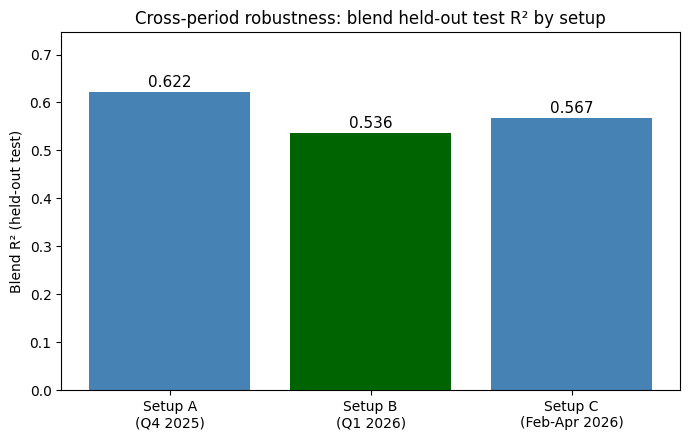

Saved fig8_cross_period_robustness.png/.pdf to paper/figures/


In [8]:
blend_rows = results[results['model'] == 'Blend (SLSQP)'].set_index('setup')
setup_labels = {'A': 'Setup A\n(Q4 2025)', 'B': 'Setup B\n(Q1 2026)', 'C': 'Setup C\n(Feb-Apr 2026)'}
labels = [setup_labels[s] for s in ['A', 'B', 'C']]
r2_vals = [blend_rows.loc[s, 'test_r2'] for s in ['A', 'B', 'C']]

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['steelblue', 'darkgreen', 'steelblue']
bars = ax.bar(labels, r2_vals, color=colors)
for bar, v in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)
ax.set_ylabel('Blend R² (held-out test)')
ax.set_title('Cross-period robustness: blend held-out test R² by setup')
ax.set_ylim(0, max(r2_vals) * 1.2)
plt.tight_layout()
plt.savefig(OUT.parent / 'paper' / 'figures' / 'fig8_cross_period_robustness.png', dpi=300, bbox_inches='tight')
plt.savefig(OUT.parent / 'paper' / 'figures' / 'fig8_cross_period_robustness.pdf', bbox_inches='tight')
plt.show()
print('Saved fig8_cross_period_robustness.png/.pdf to paper/figures/')

## 9. Full Model-Comparison Figure (All 3 Setups Side by Side)

Goes further than Ali's single blend-only figure: every model's held-out test R² across
every setup, to check whether the *same* model ranking (not just the blend) holds across
periods.

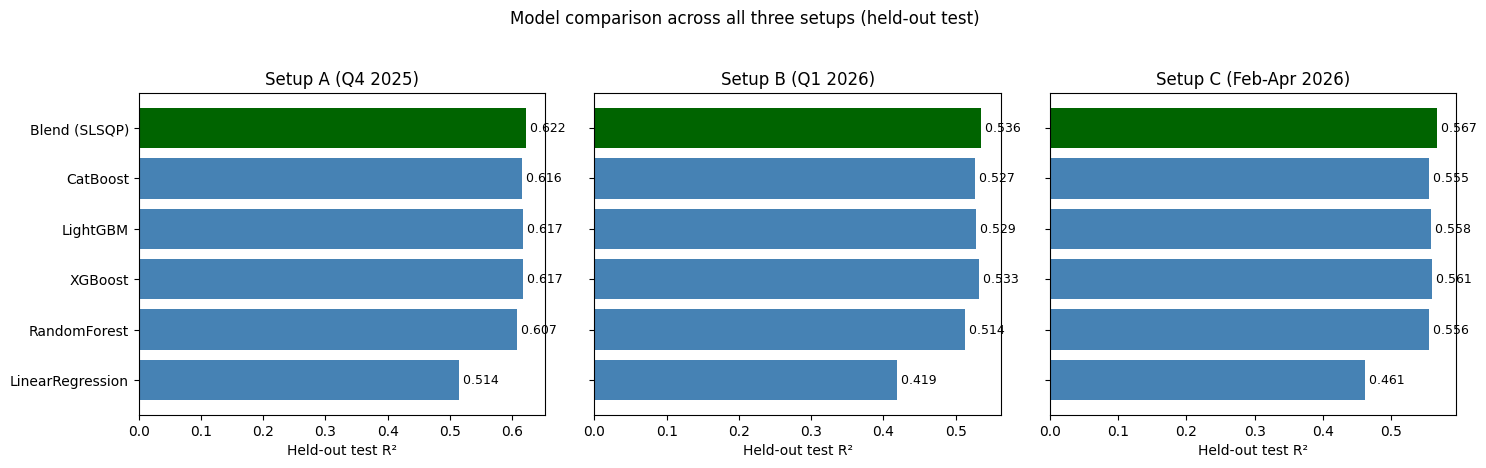

Saved fig9_model_comparison_all_setups.png/.pdf to paper/figures/


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (setup_name, _, _, _, target_label) in zip(axes, SETUPS):
    sub = results[results['setup'] == setup_name].set_index('model')
    order = MODEL_NAMES + ['Blend (SLSQP)']
    vals = [sub.loc[m, 'test_r2'] for m in order]
    colors = ['darkgreen' if m.startswith('Blend') else 'steelblue' for m in order]
    ax.barh(order, vals, color=colors)
    for i, v in enumerate(vals):
        ax.text(v, i, f' {v:.3f}', va='center', fontsize=9)
    ax.set_title(f'Setup {setup_name} ({target_label})')
    ax.set_xlabel('Held-out test R²')
plt.suptitle('Model comparison across all three setups (held-out test)', y=1.03)
plt.tight_layout()
plt.savefig(OUT.parent / 'paper' / 'figures' / 'fig9_model_comparison_all_setups.png', dpi=300, bbox_inches='tight')
plt.savefig(OUT.parent / 'paper' / 'figures' / 'fig9_model_comparison_all_setups.pdf', bbox_inches='tight')
plt.show()
print('Saved fig9_model_comparison_all_setups.png/.pdf to paper/figures/')

## Summary

Cross-period robustness check complete: the SLSQP blend, XGBoost, LightGBM, and CatBoost --
all with hyperparameters reused unchanged from Setup B's own tuning, no per-setup re-tuning --
were evaluated on a genuinely held-out 20% test split for three different history/target
windows. See Section 7's table and Section 8's figure for whether the approach's accuracy
holds up outside the single Q1 2026 quarter the rest of this project was built and tuned
against.